This notebook performs maximum likelihood fitting on SWA-PAS proton data. First we import the necessary modules and packages

In [1]:
# %%
import os

# Change current working directory to Project2
project_dir = '/disk/plasma2/cio/Project2/cleaned_code'
os.chdir(project_dir)

import numpy as np
# import matplotlib.pyplot as plt
import matplotlib as mpl
# import scipy.constants as sc
# import cmocean

from solo_spice_2 import get_radial_distance_PAS

from Poisson_fit_functions_2 import *
from gen_funcs_2 import *
from plot_funcs_2 import *
from fit_models_2 import *
from gof_funcs import *
from load_data_functions_2_v2 import *

mpl.rcParams['font.size'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['figure.figsize'] = [7, 7]

Load the data to be fitted. Ensure the files are saved in the appropriate format and location.

In [2]:
"Load the data"
# Define the start and end dates as [year, month, day, hour, minute, second]
start_date = [2023, 5, 1, 0, 0, 0]
end_date = [2023, 5, 1, 23, 59, 59]
day_span = (end_date[2] - start_date[2]) + 1  # Number of days in the range
date1_str = f"{start_date[0]}", f"{start_date[1]:02d}", f"{start_date[2]:02d}", start_date[3], start_date[4], start_date[5]

# Load PAS data in given range
coords, moms, vdfs, l1 = load_PAS_data_by_daterange(start_date, end_date, frame='SRF', rtn_rot=False)

# Unpack the loaded data
phi, theta, energy = coords
t_mom, n, T, v_bulk, P_tensor = moms
t_vdf_og, vdf, qf = vdfs
t_l1, counts = l1
R_pas = get_radial_distance_PAS(date1_str, day_span, t_vdf_og)

print(f"Loaded {len(t_vdf_og)} VDF time points from {start_date[0]}-{start_date[1]:02d}-{start_date[2]:02d} to {end_date[0]}-{end_date[1]:02d}-{end_date[2]:02d}")

# Load magnetic field data in SRF frame
t_B, B = load_MAG_data_by_daterange(start_date, end_date, frame='SRF')

print(f"Loaded {len(t_B)} magnetic field data points.")

✓ Found files for 20230501: solo_L2_swa-pas-vdf_20230501_V02.cdf, solo_L2_swa-pas-grnd-mom_20230501_V02.cdf, solo_L1_swa-pas-3d_20230501_V01.cdf
Loaded 17412 VDF time points from 2023-05-01 to 2023-05-01
✓ Found MAG file for 20230501: solo_L2_mag-srf-normal_20230501_V01.cdf
Loaded 691198 magnetic field data points.


We perform data pre-processing to format and filter the data in the appropriate format.

1. Create the velocity grid in the local magnetic field direction, based on the Spacecraft  Frame (SRF).
1. Match the L1 Counts and L2 VDF timestamps.
1. Obtain the averagae 1 count VDF value for each PAS pixel.
1. Replace filled values with the appropriate counts based on the 1 count average.
1. Determine average G factors and use the average when Counts = 0
1. Filter low enegry artefacts and high energy alpha particles.
1. Remove isolated points..
1. Determine errors based on Gaussian approximation of Poisson errors (used only for plotting error bars)

We plot the energy time series before and after filtering.

100%|██████████| 17412/17412 [00:10<00:00, 1615.14it/s]


Count and VDF shapes do not match, filling counts based on VDF time stamps...


/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:707: RuntimeWarning: invalid value encountered in divide
  c1_mean = np.nanmean(vdf / counts_nans, axis=0)  # mean 1 count vdf value per pixel
/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:707: RuntimeWarning: Mean of empty slice
  c1_mean = np.nanmean(vdf / counts_nans, axis=0)  # mean 1 count vdf value per pixel
/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:708: RuntimeWarning: invalid value encountered in divide
  c1_max = np.nanmax(vdf / counts_nans, axis=0)  # max 1 count vdf value per pixel
/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:708: RuntimeWarning: All-NaN slice encountered
  c1_max = np.nanmax(vdf / counts_nans, axis=0)  # max 1 count vdf value per pixel



            *****************************************************************************************
            Datapoints found where VDF = 0 and Counts has filled value. Filled values replaced with 0
            *****************************************************************************************
            


/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:832: RuntimeWarning: divide by zero encountered in divide
  G = counts_nans * (sc.m_p ** 2) / (2 * dt * vdf * den)
/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:832: RuntimeWarning: invalid value encountered in divide
  G = counts_nans * (sc.m_p ** 2) / (2 * dt * vdf * den)


Duration: 0:00:12.819401


100%|██████████| 17412/17412 [00:05<00:00, 3322.93it/s]
/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:1020: RuntimeWarning: divide by zero encountered in log10
  values = np.log10(values)  # take log10.
/disk/plasma2/cio/Project2/cleaned_code/gen_funcs_2.py:1026: RuntimeWarning: divide by zero encountered in log10
  values_filt = np.log10(values_filt)  # take log10.


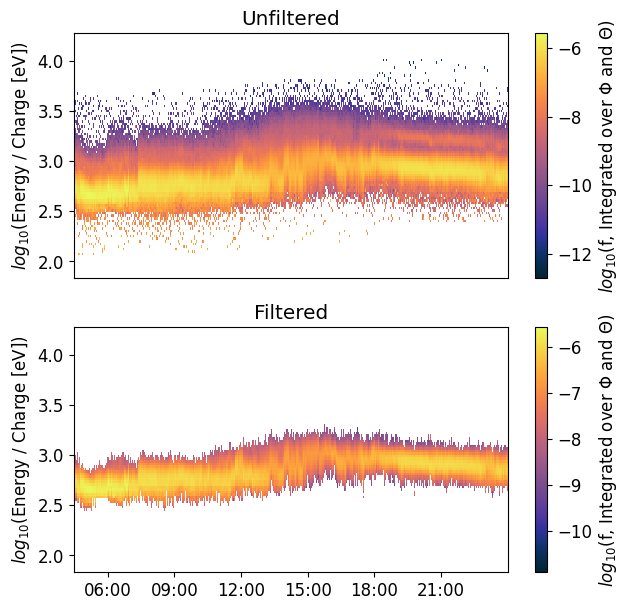

In [3]:
"Define PAS grid and rotate parameters to B field frame ([parallel, perp1, perp2])"

"Define global grid (same for each data point)"
ele, azi, ene = np.meshgrid(theta, phi, energy)
speed = E_to_v(ene)
vels = E_to_v(energy)*1e-3

vx = - speed * np.cos(ele * np.pi / 180) * np.cos(azi * np.pi / 180)
vy = speed * np.cos(ele * np.pi / 180) * np.sin(azi * np.pi / 180)
vz = - speed * np.sin(ele * np.pi / 180)

temp_v = np.stack((vx, vy, vz), axis=0)

"Function rotates the bulk vectors to the B field frame"
B_all, R_all, v_bulk_bf, P_bf, vx_bf, vy_bf, vz_bf, T_par, T_perp = define_pas_grid_parallel(theta, phi, energy, t_vdf_og, n, v_bulk, P_tensor, t_B, B, n_workers=32)  # Adjust number of workers as needed
B_mag = np.linalg.norm(B_all, axis = 1) # in nT

"""
CHECK THAT COUNTS SHAPE MATCHES VDF
IF NOT, COUNTS LIKELY HAS MORE DATAPOINTS AND NEEDS TO BE ADJUSTED
"""
counts = Check_count_shape(t_vdf_og, t_l1, vdf, counts)

"GET AVERAGE 1 COUNT VDF VALUE FOR EACH PIXEL IN THE PAS GRID"
dt = 1 / (9 * 96)  # PAS time acquisition per pixel
c1_mean, c1_max, counts_nans = average_1count(counts, vdf, dt)

"""
REPLACE FILL VALUES WITH VDF / 1C_VDF VALUES AT TIME INSTANCE AND PIXELS
WHERE VDF IS NOT ZERO BUT COUNT HAS FILLED VALUES
"""
counts = counts_fill(vdf, counts, c1_max)

"""
NEED TO USE AVERAGE G FACTORS TO FILL GAPS WHERE COUNTS AND VDF ARE ZERO (HENCE GIVING A NAN G FACTOR) 
"""
"Replace non-finite values (0 measurement) with mean G value"
# G_factors, G_factors_og, G_mean = fill_zero_gaps(vdf, counts_nans, energy, dt)
G_factors, G_factors_og, G_mean = fill_zero_gaps_sliding_mean(vdf, counts_nans, energy, dt, t_vdf_og, block_cols = 2000)

"TRY 2D K MEANS to Filter alpha particles"
vdf_in, vdf_in_0, counts_in, counts_in_0, ind_f_all, ind_e_all = kmeans_filter_parallel(vdf, counts, theta, energy)

"Remove isolated points in the VDF"
counts_in, vdf_in = remove_isolated_points_parallel(counts_in, vdf_in, n_points = 0, n_workers=8)

"Determine Poisson error for VDF"
errors_in = Errors_f(vdf_in, counts_in)

"PLOT THE ENERGY TIME SERIES"
plot_E_time_series(vdf, vdf_in, t_vdf_og, energy, theta, phi)

Perform the fit on the formatted data. Uses parallelisation to increase speed.

Two models are currently available:
1. Core+beam bi-Maxwellians
2. Single bi-Maxwellian core

The data are saved as H5 file. If an H5 file with the same name is found, the data will be appended on that file.

In [ ]:
"""
FIT AND SAVE DATA!
pick_model_fitting determines which fitting model to use.
--------------------------------------------------------------------------------------------------------------------
pick_model = 0 - Separate core and beam fit, only parallel drift, pick beam direction automatically!
pick_model = 1 - Core and beam fit together, only parallel drift, pick beam direction automatically!
--------------------------------------------------------------------------------------------------------------------
"""

pick_model_fitting = 0
method_in = 'powell'  # 'powell' or 'differential_evolution'
file_name = 'test_result1'

"This function performs the fit and saves the data in an h5 file. New data are appended to the file"
# Core + Beam
fit_data_h5_new(0, t_vdf_og, vdf_in, vx_bf, vy_bf, vz_bf, counts_in, n, v_bulk_bf, T_par, T_perp, T, G_factors, B_all, vels, theta, R_pas, qf, method_in = method_in, file_name=file_name, n_workers=50)
# Core only
# fit_data_h5_new(1, t_vdf_og, vdf_in, vx_bf, vy_bf, vz_bf, counts_in, n, v_bulk_bf, T_par, T_perp, T, G_factors, B_all, vels, theta, R_pas, qf, method_in = method_in, file_name=file_name, n_workers=50)


# Saved data contents and format
"""
The saved H5 file parameter names and content:
    1. 'fit_parameters' - the fitted parameters, shape 12. Parameter order is:
        - 0 => n_c = core density
        - 1 => vx_c = core parallel velocity
        - 2, 3 => vy_c, vz_c = core perpendicular velocities
        - 4, 5 => vth_par_c, vh_perp_c = core parallel and perpendicular thermal velocities 
        - 6 => n_b = beam density
        - 7 => vx_b = beam parallel velocity
        - 8, 9 => vy_b, vz_b = beam perpendicular velocities
        - 10, 11, => vth_par_b, vh_perp_c = beam parallel and perpendicular thermal velocities 
    2. 'initil_conditions' - initial conditions of fit, shape 12
    3. 'contraints' - shape (3, 12) => min constraints, max constraints, flag if min or max constraint was hit
    4. 'overlap' - shape (2) => 1d overlap and 3d overlap
    5. 'ks' - KS metric related variables, shape (2)
    5. 'D' - Deviance metric related variables, shape (3)
    6. 'time' - time of measurement as a timestamp, shape (1)
    7. 'R' - radial distance of SolO from Sun, shape (1)
    8. Moments parameters: 'n', 'v', 'T_par', 'T_perp'
    9. 'B' - magnetic filed 3D measurements in SRF shape (3)
    10. 'qf' - quality values for PAS data shape (1)
    11. 'success' - success boolean of fit (3): core+beam model performs 3 fits
    12. 'counts' - count related quantities (total counts, max counts, number of total datapoints - free parameters), shape (3)
    """

Fitting progress:   3%|▎         | 565/17412 [00:10<04:29, 62.52it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting progress:   4%|▎         | 616/17412 [00:11<04:13, 66.24it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting progress:   4%|▎         | 623/17412 [00:11<05:03, 55.41it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting progress:   4%|▍         | 657/17412 [00:11<04:23, 63.52it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting progress

Worker error1: cannot access local variable 'param_names' where it is not associated with a value


Fitting progress:  63%|██████▎   | 10962/17412 [03:01<01:49, 59.06it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting progress:  63%|██████▎   | 10969/17412 [03:01<02:14, 47.96it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting progress:  63%|██████▎   | 10975/17412 [03:02<02:27, 43.59it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting progress:  63%|██████▎   | 10980/17412 [03:02<02:24, 44.62it/s]/disk/plasma2/cio/Project2/cleaned_code/fit_models_2.py:3536: RuntimeWarning: invalid value encountered in scalar divide
  overlap_3d = np.nansum(min_fit) / np.nansum(beam_fit)
Fitting 

Duration: 0:00:00.489253


"\nThe saved H5 file parameter names and content:\n    1. 'fit_parameters' - the fitted parameters, shape 12. Parameter order is:\n        - 0 => n_c = core density\n        - 1 => vx_c = core parallel velocity\n        - 2, 3 => vy_c, vz_c = core perpendicular velocities\n        - 4, 5 => vth_par_c, vh_perp_c = core parallel and perpendicular thermal velocities \n        - 6 => n_b = beam density\n        - 7 => vx_b = beam parallel velocity\n        - 8, 9 => vy_b, vz_b = beam perpendicular velocities\n        - 10, 11, => vth_par_b, vh_perp_c = beam parallel and perpendicular thermal velocities \n    2. 'initil_conditions' - initial conditions of fit, shape 12\n    3. 'contraints' - shape (3, 12) => min constraints, max constraints, flag if min or max constraint was hit\n    4. 'overlap' - shape (2) => 1d overlap and 3d overlap\n    5. 'goodness_metric' - goodness of fit metric, shape (1)\n    6. 'time' - time of measurement as a timestamp, shape (1)\n    7. 'R' - radial distance o

Load and format the data

In [ ]:
"Load data"
file_name = 'test_result1'
data = load_results_h5(file_name)

nc_all, vc_all, vth_par_c_all, vth_perp_c_all, nb_all, vb_all, vth_par_b_all, vth_perp_b_all, fitted_params, in_conds, constraint_flag_all, overlap_all_3d, ks_all, D_all, t_vdf, R_all, n_all, v_all, T_par_all, T_perp_all, B_3d, qf_all, success_all, counts_all = format_data_h5_new(data)
# nc_all, vc_all, vth_par_c_all, vth_perp_c_all, fitted_params, in_conds, constraint_flag_all, overlap_all_3d, ks_all, D_all, t_vdf, R_all, n, v_bulk, T_par, T_perp, B_3d, qf_all = format_data_h5_core_new(data)
ks, p = ks_all[:, 0], ks_all[:, 1]
D_norm, L_mean, L_std = D_all[:, 0], D_all[:, 1], D_all[:, 2]
B_fit_all = np.linalg.norm(B_3d, axis=1)


[ 259. 6570. 1398.]


Plot fits against the data

  0%|          | 0/1 [00:00<?, ?it/s]

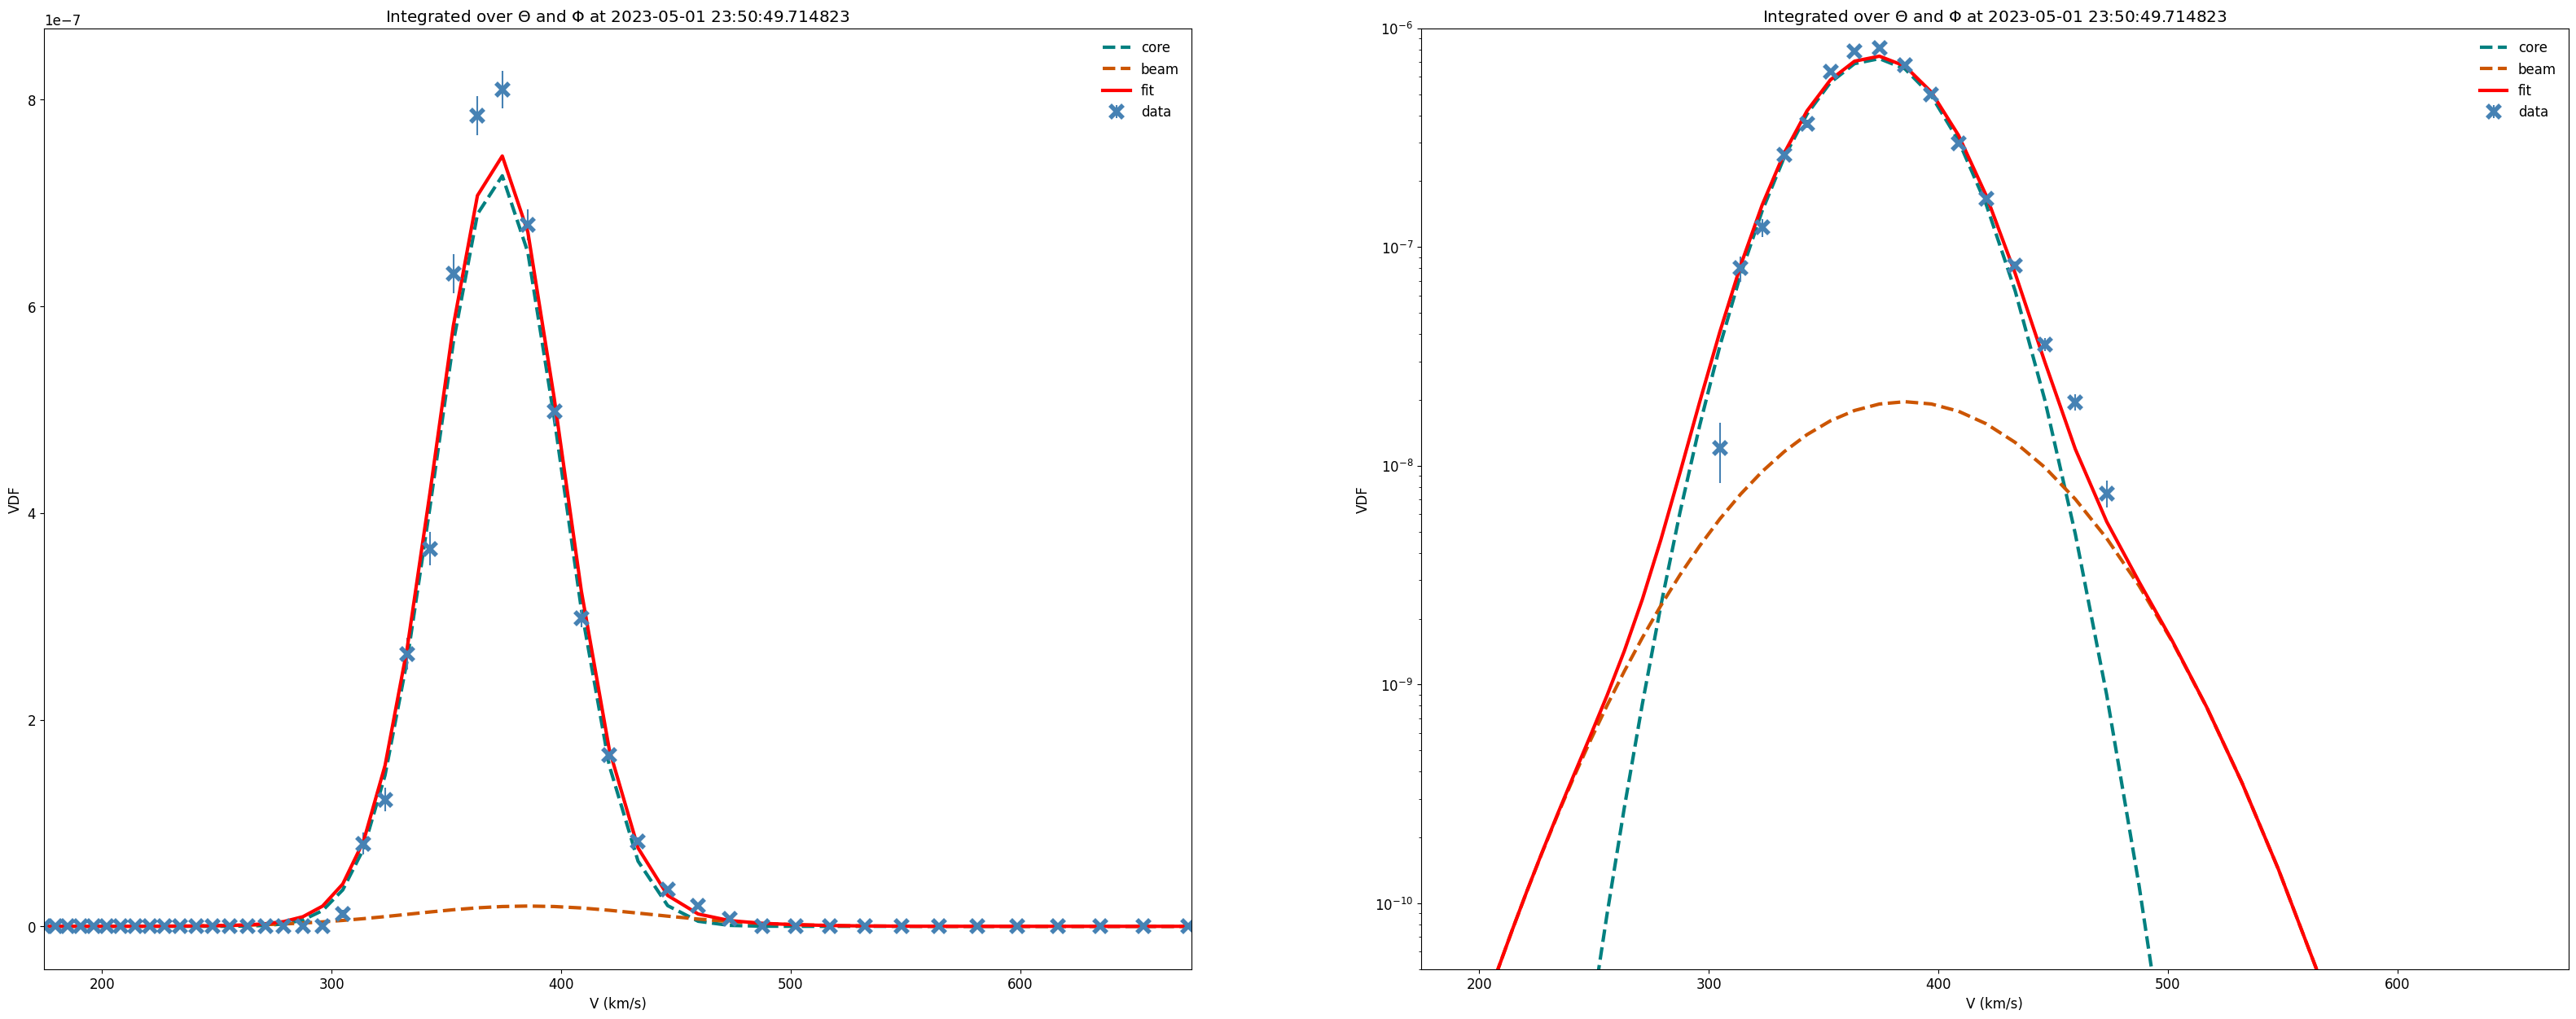

100%|██████████| 1/1 [00:00<00:00,  1.70it/s]


In [6]:
"Plot the fits"
# Target time for plot
target_time = datetime.datetime(2023, 5, 1, 23, 50, 44)
target_index = np.argmin(np.abs(np.array([(t - target_time).total_seconds() for t in t_vdf])))


target_index2 = np.argmin(np.abs(np.array([(t - target_time).total_seconds() for t in t_vdf_og])))
lims = [5e-11, 1e-6]  # Adjust limits as needed
plot_3D = False  # Set to True if you want to plot in 3D
save = False  # Set to True if you want to save the plots
parameters = ([nc_all[target_index] *1e6], [vc_all[target_index]*1e3], [vth_par_c_all[target_index]], [vth_perp_c_all[target_index]], [nb_all[target_index]*1e6], [vb_all[target_index]*1e3], [vth_par_b_all[target_index]], [vth_perp_b_all[target_index]])
# parameters = ([nc_all[target_index] *1e6], [vc_all[target_index]*1e3], [vth_par_c_all[target_index]], [vth_perp_c_all[target_index]])

folder = 'empty'

vdf_int, errors_int, vx_bft, vy_bft, vz_bft, t_vdf_int = [vdf_in[target_index2]], [errors_in[target_index2]], [vx_bf[target_index2]], [vy_bf[target_index2]], [vz_bf[target_index2]], [t_vdf[target_index2]]
core_only = False

plot_fits([0], parameters, vdf_int, errors_int, vx_bft, vy_bft, vz_bft, date1_str, t_vdf_int, theta, phi, energy, folder, lims = lims, plot_3D = plot_3D, save = save, core_only=core_only)
